# Importar datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Configuración de rutas
data_path = r"C:\Users\xXSrBiscuitXx\Documents\GitHub\ProjecteData\Equip_15\Data\RRHH_220925_clean.parquet"

try:
    df = pd.read_parquet(data_path)
    print(f"✓ Dataset cargado correctamente: {df.shape[0]} filas, {df.shape[1]} columnas")
except Exception as e:
    print(f"✗ Error cargando el archivo: {e}")
    exit()

✓ Dataset cargado correctamente: 806 filas, 25 columnas


# Correlaciones con HitTarget

                            OLS Regression Results                            
Dep. Variable:             Hit_target   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     28.19
Date:                Thu, 25 Sep 2025   Prob (F-statistic):          2.74e-155
Time:                        12:28:07   Log-Likelihood:                -1731.5
No. Observations:                 806   AIC:                             3589.
Df Residuals:                     743   BIC:                             3885.
Df Model:                          62                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

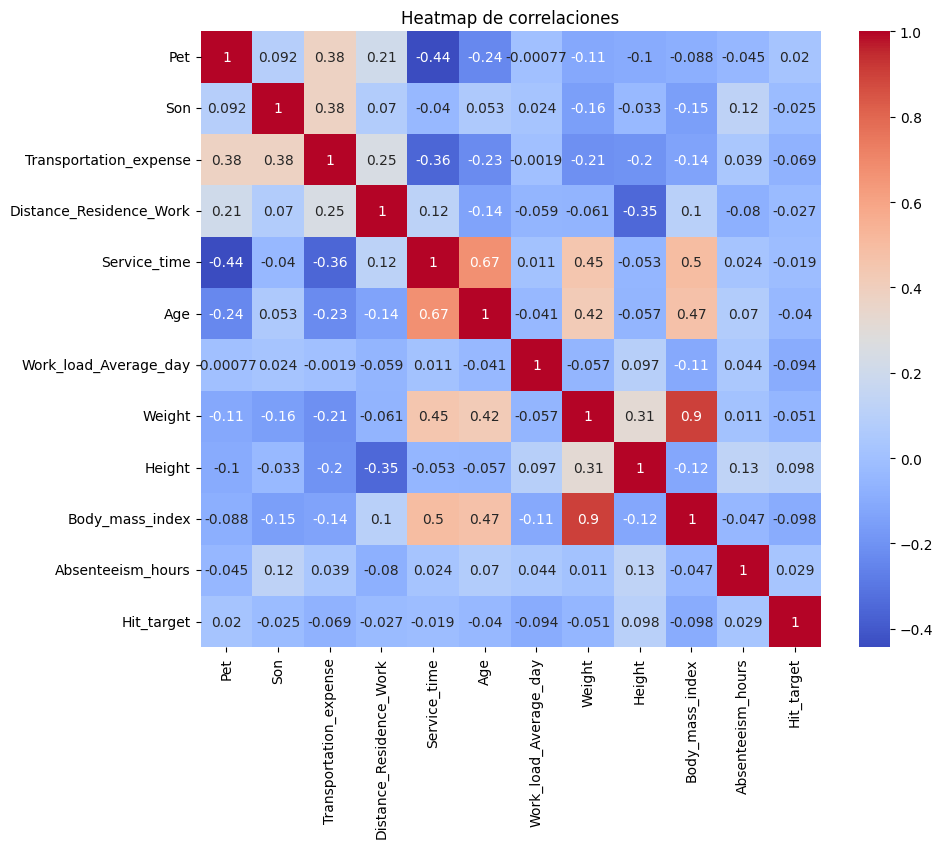

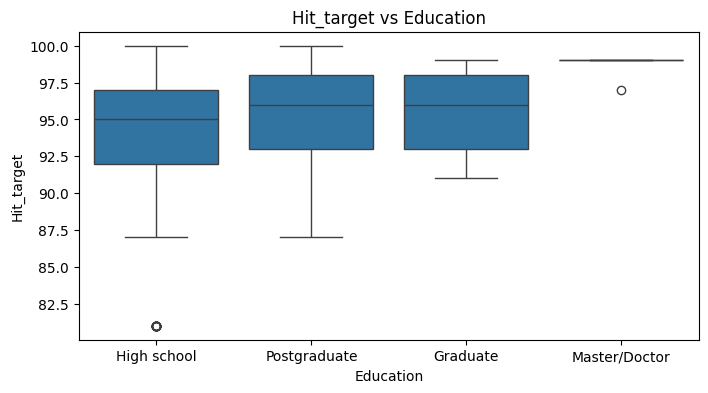

Education - p-value ANOVA: 0.0035


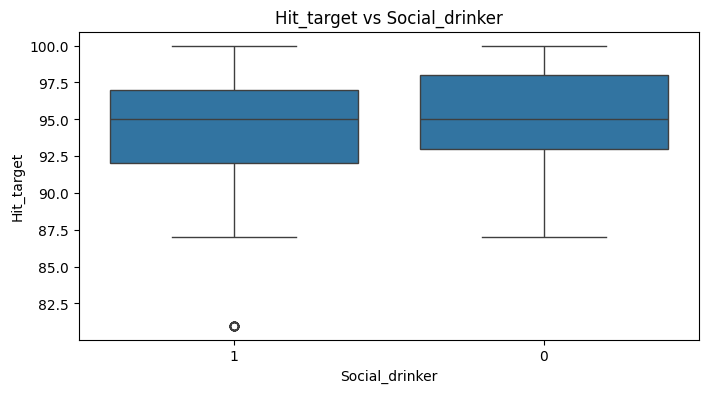

Social_drinker - p-value ANOVA: 0.0028


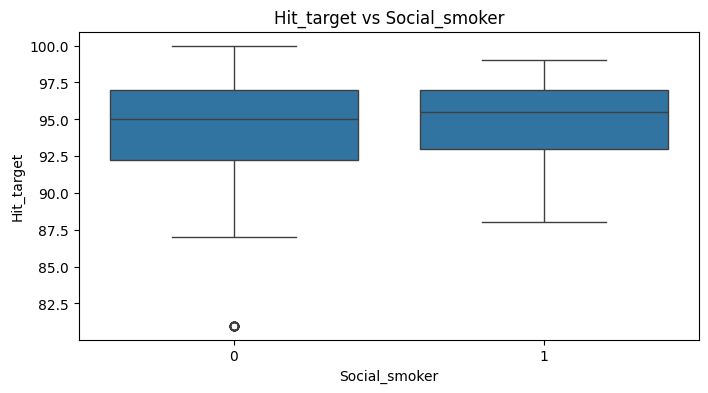

Social_smoker - p-value ANOVA: 0.1612


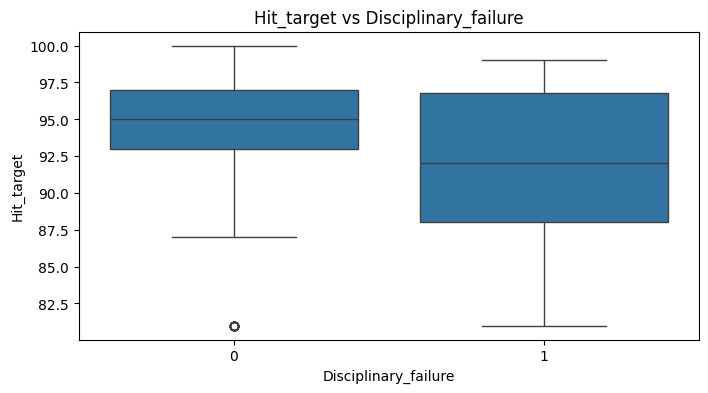

Disciplinary_failure - p-value ANOVA: 0.0000


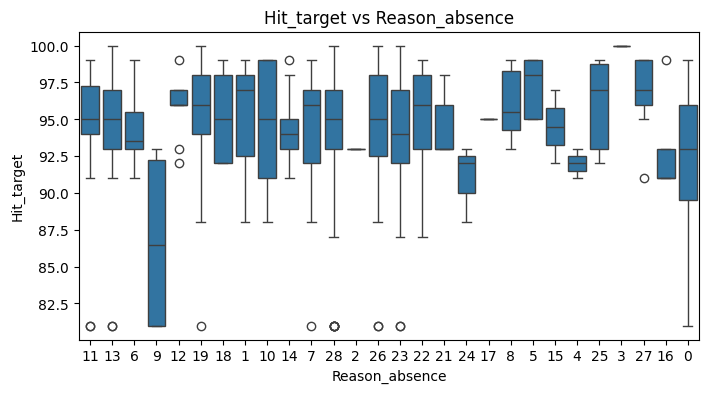

Reason_absence - p-value ANOVA: 0.0000


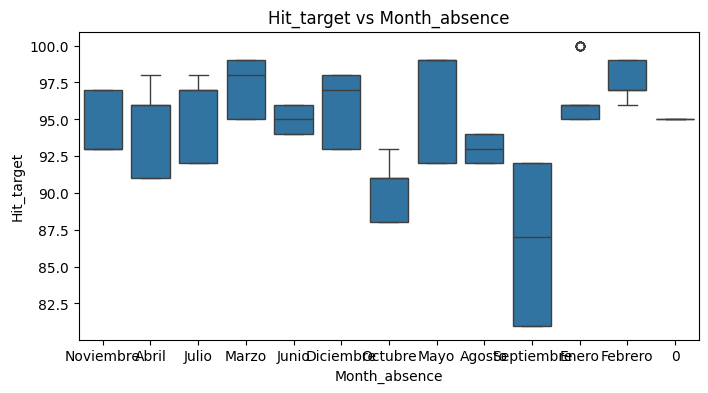

Month_absence - p-value ANOVA: 0.0000


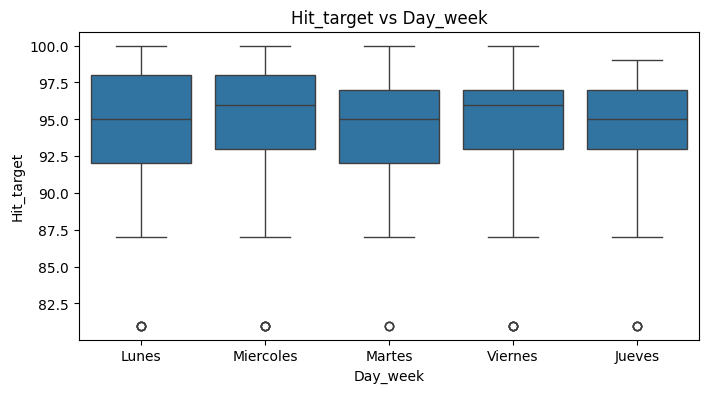

Day_week - p-value ANOVA: 0.4892


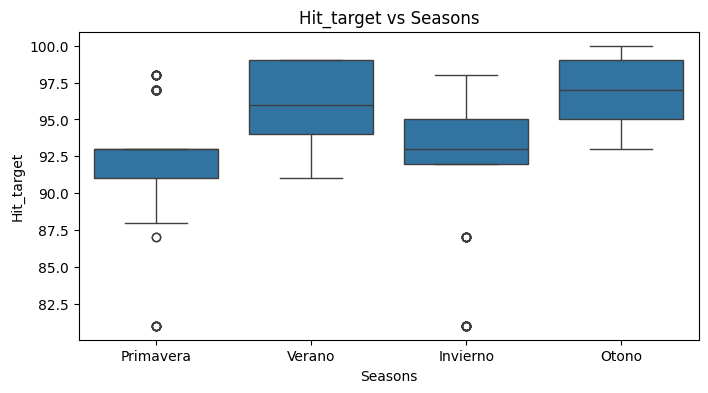

Seasons - p-value ANOVA: 0.0000


In [3]:
target = 'Hit_target'

num_vars = ['Pet', 'Son', 'Transportation_expense', 'Distance_Residence_Work',
            'Service_time', 'Age', 'Work_load_Average_day',
            'Weight', 'Height', 'Body_mass_index', 'Absenteeism_hours']

cat_vars = ['Education', 'Social_drinker', 'Social_smoker', 'Disciplinary_failure',
            'Reason_absence', 'Month_absence', 'Day_week', 'Seasons']

# Limpieza de variables categóricas
for col in cat_vars:
    df[col] = df[col].astype(str).str.strip()

# Creación de dummies
df_model = pd.get_dummies(df, columns=cat_vars, drop_first=True, dtype=float)

# Preparar X e y
X = df_model.drop(columns=[target, 'ID'])
y = df_model[target]

# Añadir constante para regresión
X = sm.add_constant(X)

# Modelo de regresión lineal múltiple
model = sm.OLS(y, X).fit()
print(model.summary())


# Exploración opcional: correlaciones y boxplots
# Correlación con numéricas
corr = df[num_vars + [target]].corr()[target].sort_values(ascending=False)
print("\nCorrelación con Hit_target:")
print(corr)

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[num_vars + [target]].corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap de correlaciones")
plt.show()

# Boxplots para categóricas
for col in cat_vars:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y=target, data=df)
    plt.title(f"{target} vs {col}")
    plt.show()
    
    # ANOVA
    groups = [group[target].values for name, group in df.groupby(col)]
    if len(groups) > 1:
        anova = stats.f_oneway(*groups)
        print(f"{col} - p-value ANOVA: {anova.pvalue:.4f}")